# Credit Card Fraud KNN Classification Project

## Data

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [ ]:
import pandas as pd
import os

file_path = os.path.join(path, 'creditcard.csv')
df = pd.read_csv(file_path)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
# Re-load the original full dataset to ensure we have all instances for sampling
df_original = pd.read_csv(file_path)

# Get the count of the minority class (Class == 1) from the original dataset
num_class_1 = df_original[df_original['Class'] == 1].shape[0]

# Sample an equal number of instances from Class == 0 and all instances from Class == 1
df_class_0 = df_original[df_original['Class'] == 0].sample(num_class_1, random_state=42)
df_class_1 = df_original[df_original['Class'] == 1] # Take all available minority class instances

# Concatenate them to form the new balanced dataframe, and assign it back to df
df = pd.concat([df_class_0, df_class_1])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 984 entries, 138028 to 281674
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    984 non-null    float64
 1   V1      984 non-null    float64
 2   V2      984 non-null    float64
 3   V3      984 non-null    float64
 4   V4      984 non-null    float64
 5   V5      984 non-null    float64
 6   V6      984 non-null    float64
 7   V7      984 non-null    float64
 8   V8      984 non-null    float64
 9   V9      984 non-null    float64
 10  V10     984 non-null    float64
 11  V11     984 non-null    float64
 12  V12     984 non-null    float64
 13  V13     984 non-null    float64
 14  V14     984 non-null    float64
 15  V15     984 non-null    float64
 16  V16     984 non-null    float64
 17  V17     984 non-null    float64
 18  V18     984 non-null    float64
 19  V19     984 non-null    float64
 20  V20     984 non-null    float64
 21  V21     984 non-null    float64
 22 

In [ ]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,...,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000,984.000000
mean,87899.782520,-2.309318,1.816713,-3.535655,2.257353,-1.544629,-0.725850,-2.777468,0.292773,-1.271887,...,0.363824,-0.003366,-0.013543,-0.056194,0.033048,0.011976,0.090822,0.036681,101.279837,0.500000
std,47991.767211,5.523248,3.675483,6.200540,3.207699,4.205316,1.726953,5.845730,4.859601,2.340829,...,2.806097,1.170228,1.164365,0.578977,0.677074,0.469889,0.999413,0.415091,221.764524,0.500254
min,406.000000,-30.552380,-8.402154,-31.103685,-4.519509,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-22.797604,-8.887017,-19.254328,-2.836627,-4.781606,-1.178778,-7.263482,-1.869290,0.000000,0.000000
25%,45928.000000,-2.784711,-0.150957,-5.084967,-0.140560,-1.775001,-1.599839,-3.066415,-0.228822,-2.353917,...,-0.164947,-0.541855,-0.245208,-0.399495,-0.309954,-0.297013,-0.062727,-0.056989,1.180000,0.000000
50%,80853.000000,-0.784459,0.940617,-1.369045,1.302623,-0.340291,-0.671683,-0.635248,0.146863,-0.702318,...,0.136882,0.035879,-0.035509,0.009479,0.058178,-0.014392,0.042484,0.031986,16.880000,0.500000
75%,134528.250000,1.125429,2.798885,0.225959,4.202830,0.492184,0.073437,0.286374,0.867939,0.192528,...,0.655130,0.553477,0.192580,0.381696,0.401022,0.289880,0.455390,0.211934,99.990000,1.000000
max,171917.000000,2.351891,22.057729,3.143387,12.114672,11.095089,6.474115,5.802537,20.007208,5.232322,...,27.202839,8.361985,6.008724,1.205581,2.208209,2.745261,3.052358,1.779364,2125.870000,1.000000


Time = 0.08803457215418316


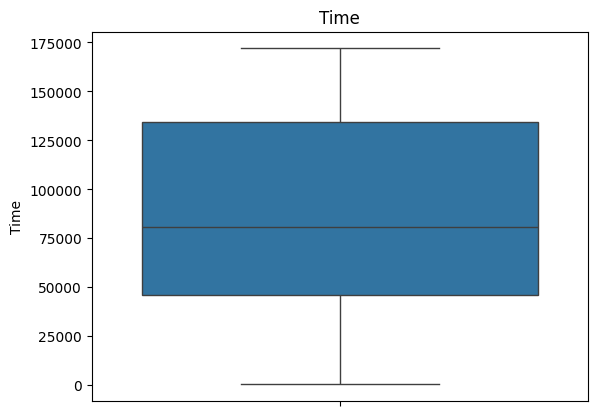



V1 = -2.628498683092452


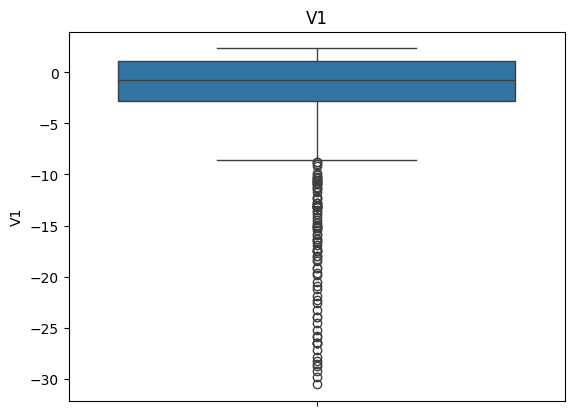



V2 = 1.8461225383607658


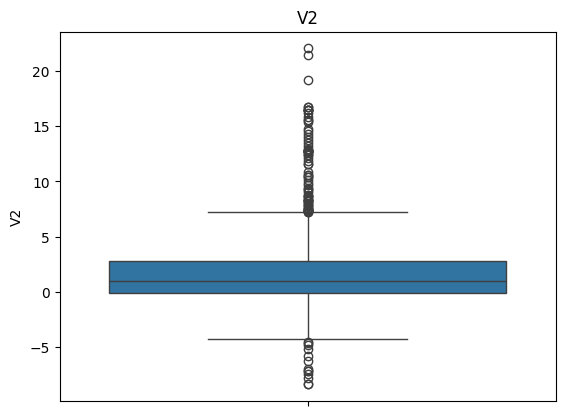



V3 = -2.214287732379755


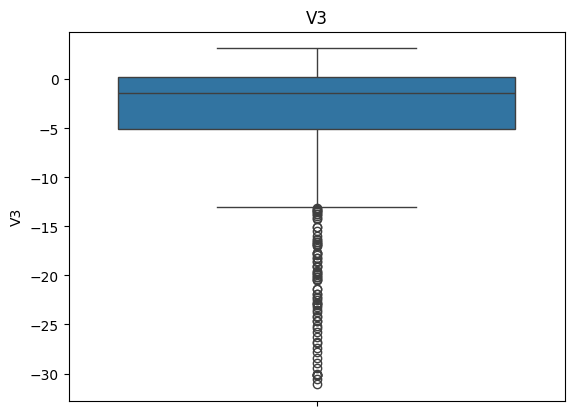



V4 = 0.8577215973117222


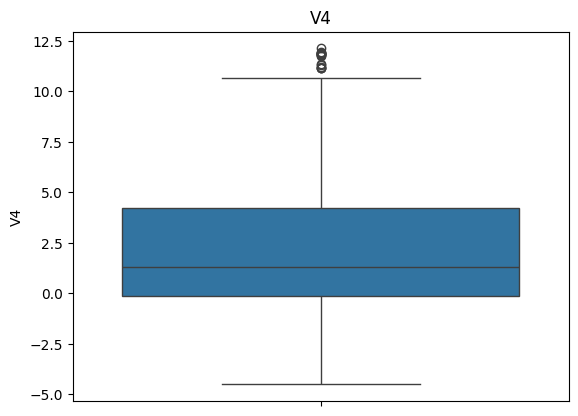



V5 = -2.3007737583615016


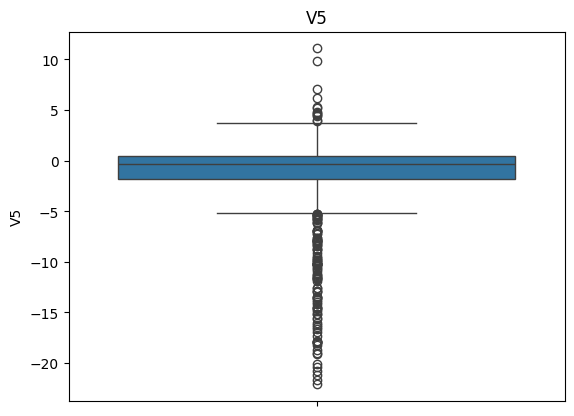



V6 = 0.41867249013006724


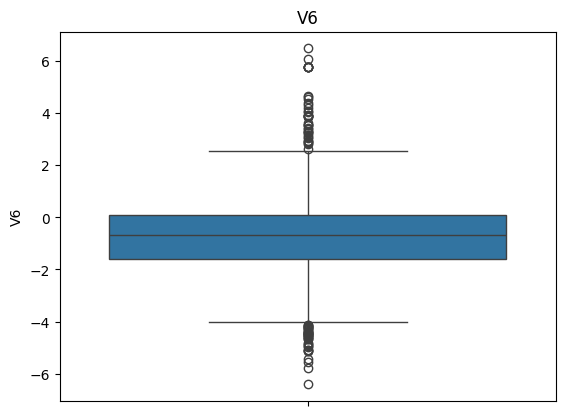



V7 = -2.7799433038097576


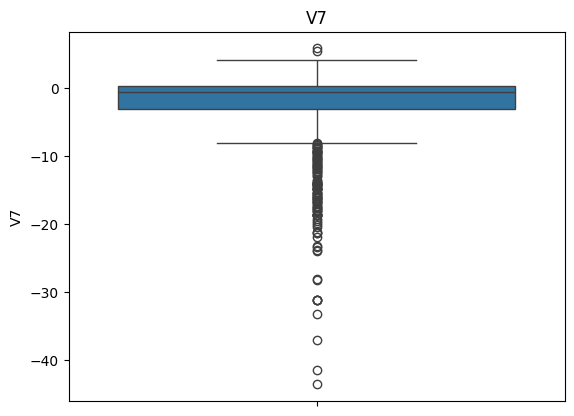



V8 = -3.7212809125414403


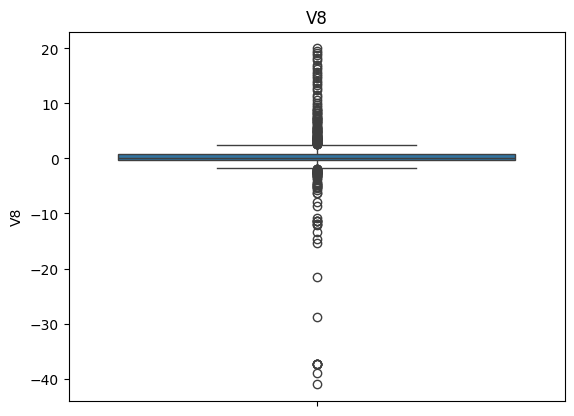



V9 = -1.3343184735899352


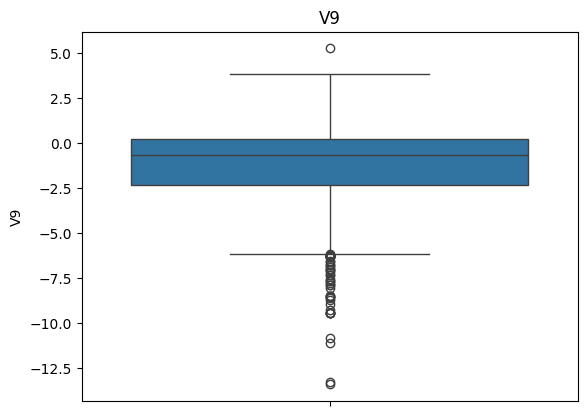



V10 = -1.7465640387073582


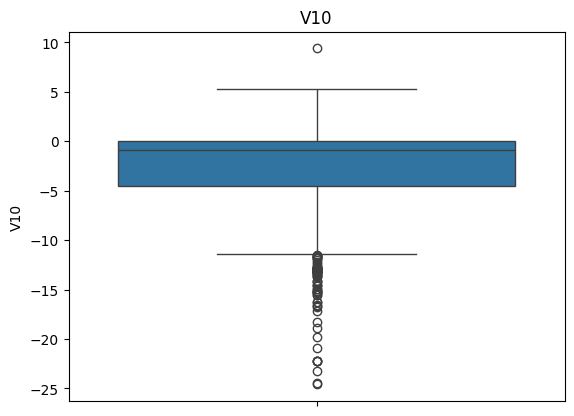



V11 = 1.065193880934212


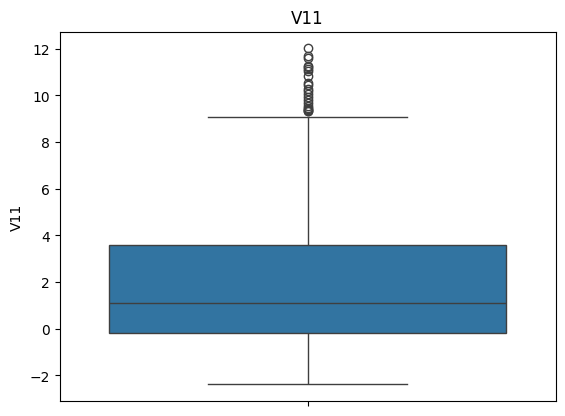



V12 = -1.3633918921429202


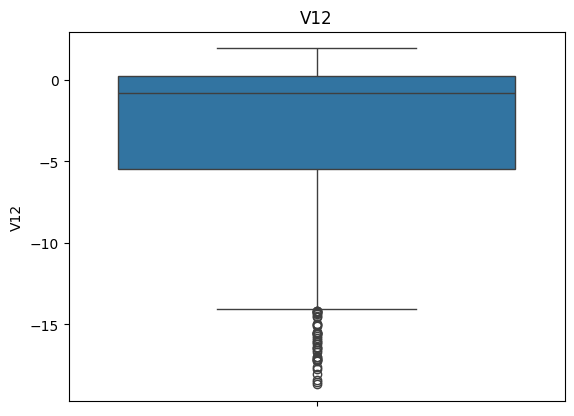



V13 = -0.015128062981949991


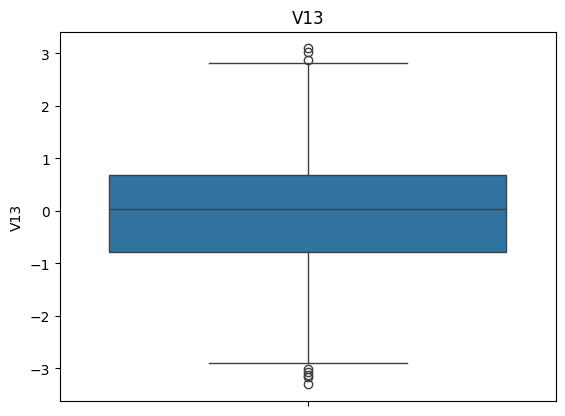



V14 = -1.0038334179027144


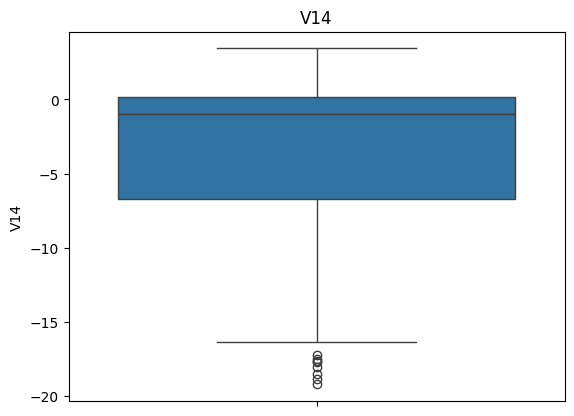



V15 = -0.4788824292819449


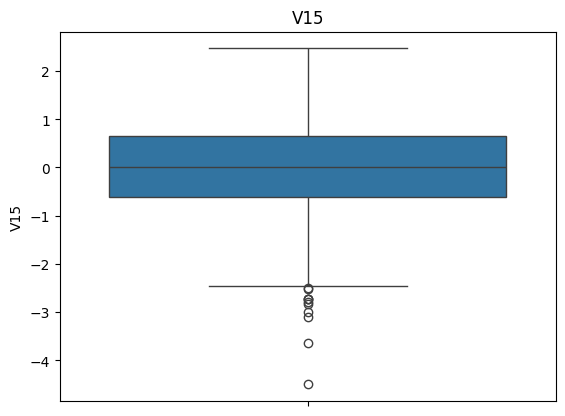



V16 = -1.4089176366010236


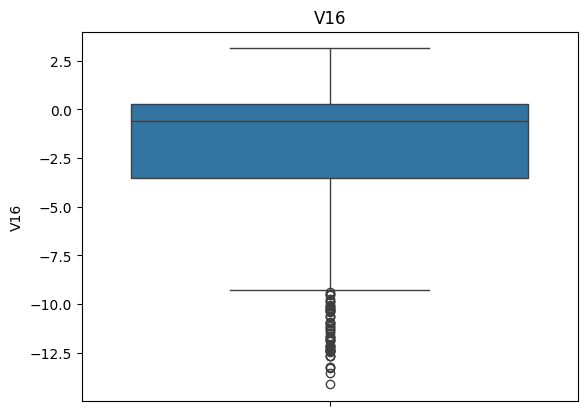



V17 = -1.5176844901997264


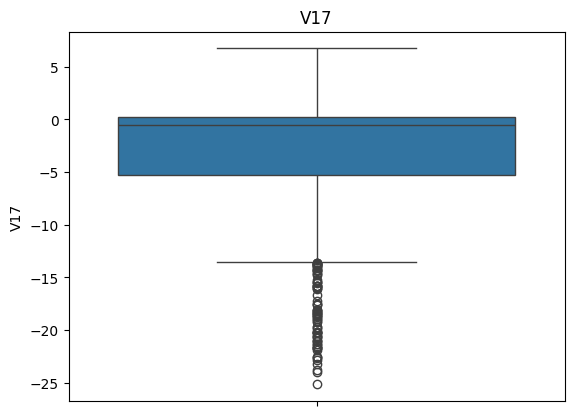



V18 = -1.3828151885336566


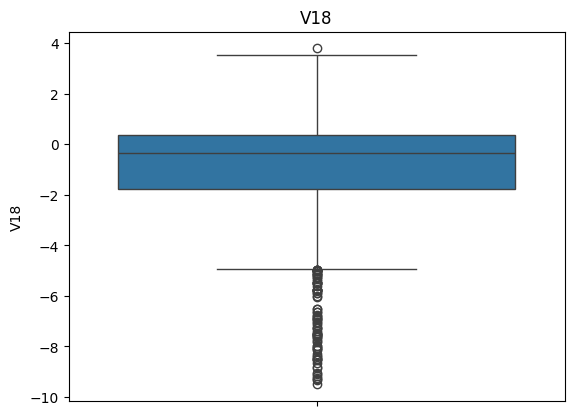



V19 = 0.5424719841309565


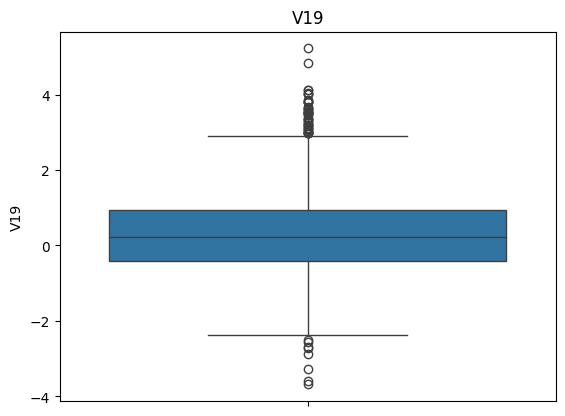



V20 = 2.516009319573488


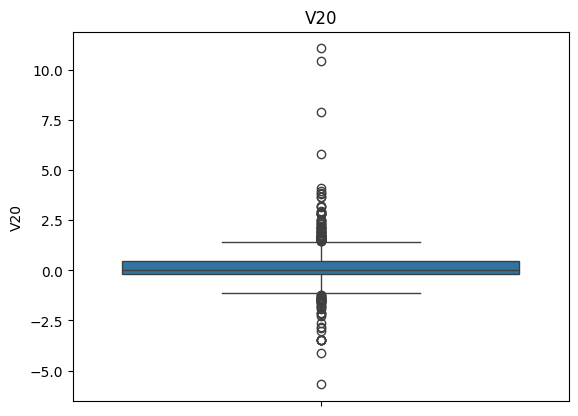



V21 = 3.9178162357169453


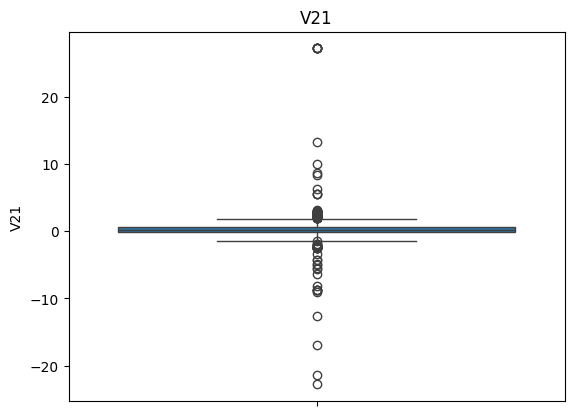



V22 = -1.5585043072344347


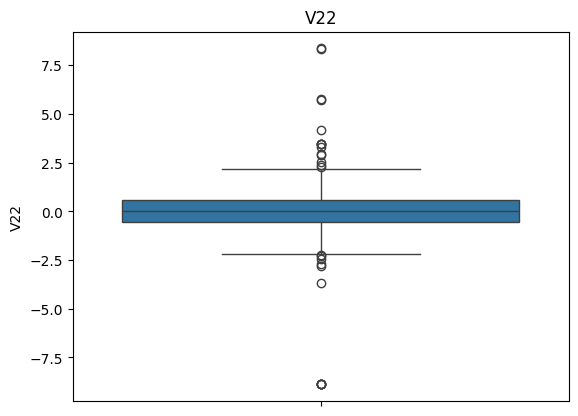



V23 = -6.605259539946183


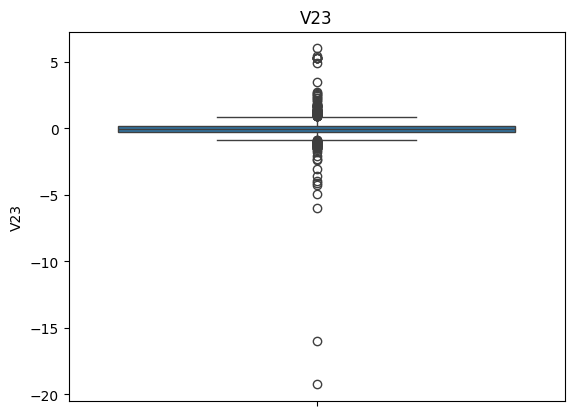



V24 = -0.6548813911894878


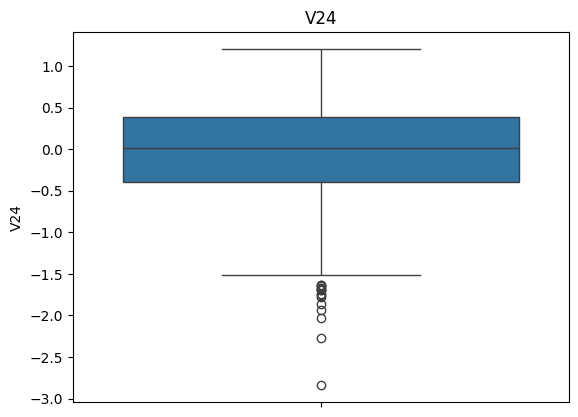



V25 = -0.6798742870007687


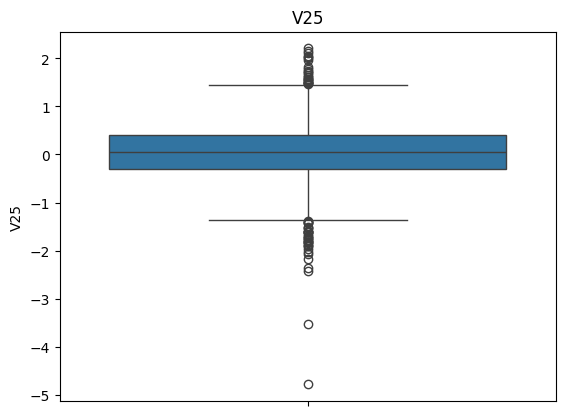



V26 = 0.5982946054271772


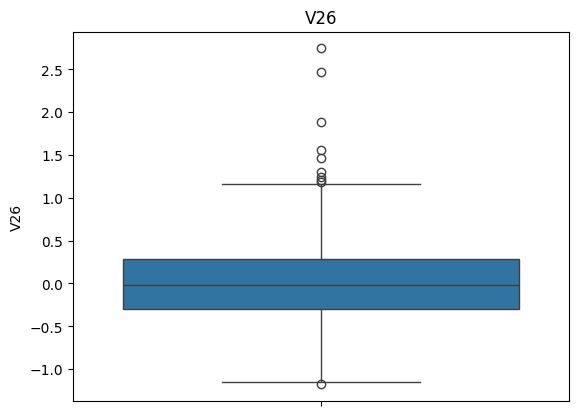



V27 = -2.717084952878916


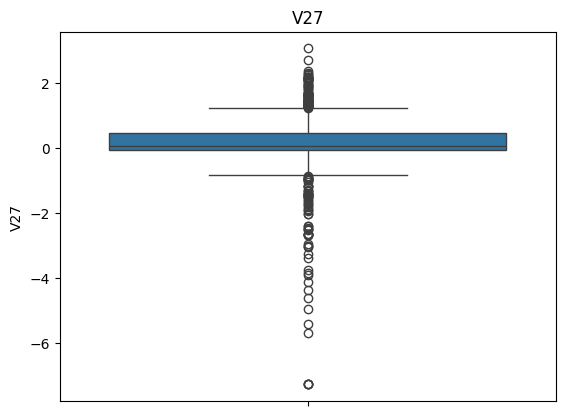



V28 = -0.7784152555132446


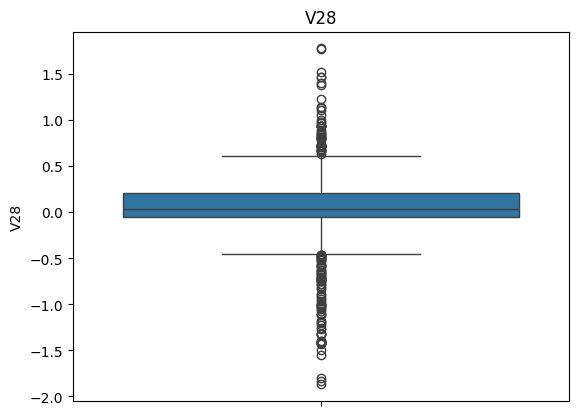



Amount = 4.146300331661583


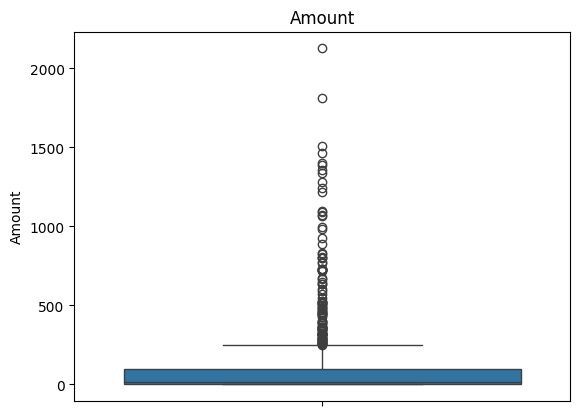



Class = 0.0


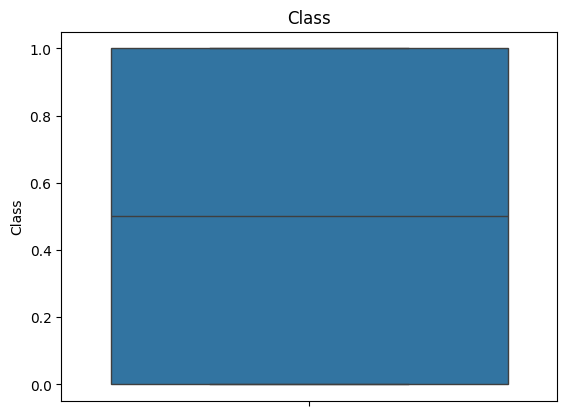

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for i in list(df.columns):
  print(f'{i} = {df[i].skew()}')
  sns.boxplot(df[i])
  plt.title(f'{i}')
  plt.show()

  print('\n')

## EDA

In [ ]:
import seaborn as sns
# sns.pairplot(df, hue = 'Class')

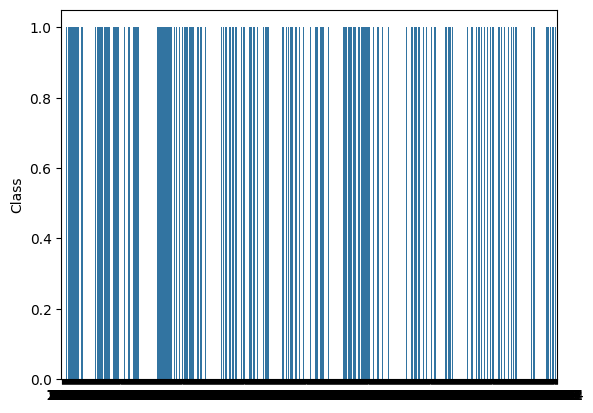

In [ ]:
sns.barplot(df['Class'])
plt.show()

## Preprocessing

In [ ]:
from scipy.stats import zscore
import numpy as np

# Identify numerical columns for outlier removal (all except 'Class')
numerical_cols = df.columns.drop('Class')

df_cleaned = df.copy()

# Calculate Z-scores for all numerical columns
z_scores = np.abs(zscore(df_cleaned[numerical_cols]))

# Define a threshold (commonly 3 for Z-score)
threshold = 3

# Filter out rows where any Z-score exceeds the threshold
outlier_mask = (z_scores > threshold).any(axis=1)
df_cleaned = df_cleaned[~outlier_mask]

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after outlier removal: {df_cleaned.shape}")
print(f"Number of outliers removed: {df.shape[0] - df_cleaned.shape[0]}")

Original DataFrame shape: (984, 31)
DataFrame shape after outlier removal: (822, 31)
Number of outliers removed: 162


In [ ]:
1300/10000


0.13

### Standardize/Normalise the numerical columns

In [ ]:
from sklearn.preprocessing import StandardScaler

# Separate features (X) and target (y)
X = df_cleaned.drop('Class', axis=1)
y = df_cleaned['Class']

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# Combine scaled features with the target variable
df_scaled = pd.concat([X_scaled_df, y], axis=1)

print("DataFrame after standardization:")
df_scaled.head()

DataFrame after standardization:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
138028,-0.187629,0.752954,-0.210014,0.349036,-0.333306,0.356864,-0.347921,0.579356,-0.415056,0.416068,...,-0.532327,-0.636136,-0.282362,-0.252976,1.049496,0.898369,-0.246024,-0.066011,-0.555612,0
63099,-0.853187,0.023122,0.074457,0.781599,-0.341755,0.321440,0.225649,0.616695,-0.162937,0.049540,...,-0.074448,0.815238,-0.171042,0.135804,-0.539683,-0.862211,-0.879503,-0.577996,-0.529724,0
73411,-0.757806,0.163874,-0.610166,0.841488,-1.111789,-0.045422,0.458993,0.196626,-0.261144,-1.040948,...,-0.487077,0.151272,-0.396655,-0.777210,-0.653241,0.014445,0.100807,0.670099,-0.447819,0
164247,0.524379,0.278130,0.017032,0.260706,-0.620105,0.303217,-0.506630,0.715137,-0.165546,0.405799,...,0.113928,1.288597,-0.003728,-0.118622,-0.707320,-0.343270,-0.227308,-0.028345,-0.129890,0
148999,-0.021030,0.937343,-0.313992,0.606696,0.877445,0.265497,1.143265,0.189379,-0.105921,0.892046,...,-0.195770,0.876057,0.484969,1.369239,-0.468049,-0.052019,-0.220633,-0.329360,-0.561365,0


Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y) from the scaled DataFrame
X = df_scaled.drop('Class', axis=1)
y = df_scaled['Class']

# Split the data into training and testing sets (80/20 ratio) with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nClass distribution in original data:")
print(y.value_counts(normalize=True))
print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (657, 30)
Shape of X_test: (165, 30)
Shape of y_train: (657,)
Shape of y_test: (165,)

Class distribution in original data:
Class
0    0.568127
1    0.431873
Name: proportion, dtype: float64

Class distribution in y_train:
Class
0    0.567732
1    0.432268
Name: proportion, dtype: float64

Class distribution in y_test:
Class
0    0.569697
1    0.430303
Name: proportion, dtype: float64


## Modeling

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver is good for small datasets

# Train the model
log_reg_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_log_reg = log_reg_model.predict(X_test)

print("First 5 predictions:")
print(y_pred_log_reg[:5])

First 5 predictions:
[0 1 0 1 0]


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95        94
           1       0.97      0.89      0.93        71

    accuracy                           0.94       165
   macro avg       0.94      0.93      0.94       165
weighted avg       0.94      0.94      0.94       165


Accuracy: 0.9394
ROC AUC Score: 0.9700


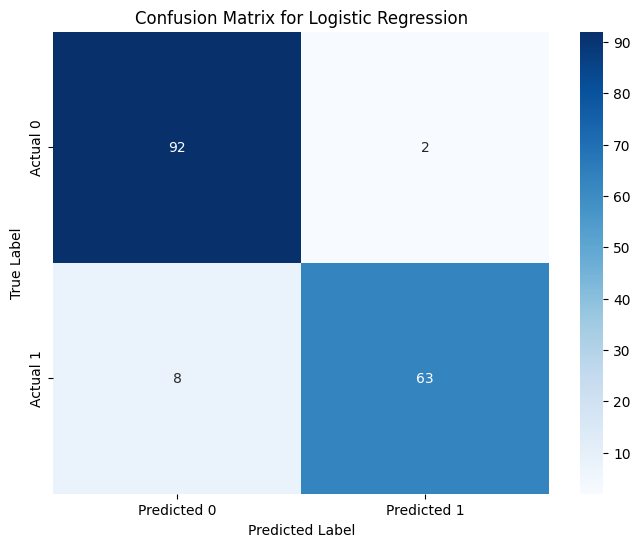

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Generate classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_log_reg))

# Calculate Accuracy
accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"\nAccuracy: {accuracy:.4f}")

# Calculate ROC AUC
roc_auc = roc_auc_score(y_test, log_reg_model.predict_proba(X_test)[:, 1])
print(f"ROC AUC Score: {roc_auc:.4f}")

# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred_log_reg)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

### KNN

First 5 KNN predictions:
[0 1 0 1 0]

Classification Report for KNN:
              precision    recall  f1-score   support

           0       0.90      0.99      0.94        94
           1       0.98      0.86      0.92        71

    accuracy                           0.93       165
   macro avg       0.94      0.92      0.93       165
weighted avg       0.94      0.93      0.93       165


KNN Accuracy: 0.9333
KNN ROC AUC Score: 0.9419


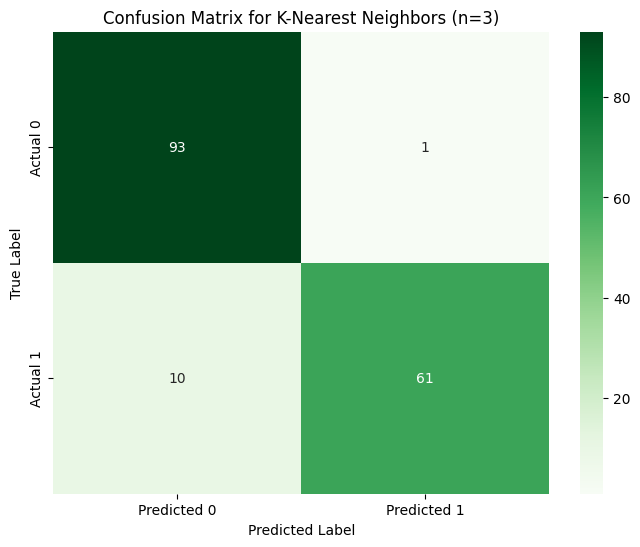

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize the KNN model with n_neighbors = 3
knn_model = KNeighborsClassifier(n_neighbors=3)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_model.predict(X_test)

print("First 5 KNN predictions:")
print(y_pred_knn[:5])

# Generate classification report for KNN
print("\nClassification Report for KNN:")
print(classification_report(y_test, y_pred_knn))

# Calculate Accuracy for KNN
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"\nKNN Accuracy: {accuracy_knn:.4f}")

# Calculate ROC AUC for KNN (requires probability predictions)
roc_auc_knn = roc_auc_score(y_test, knn_model.predict_proba(X_test)[:, 1])
print(f"KNN ROC AUC Score: {roc_auc_knn:.4f}")

# Generate confusion matrix for KNN
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for K-Nearest Neighbors (n=3)')
plt.show()

### Tuning KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

# Find best K
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K: {best_k}")

Best K: 3


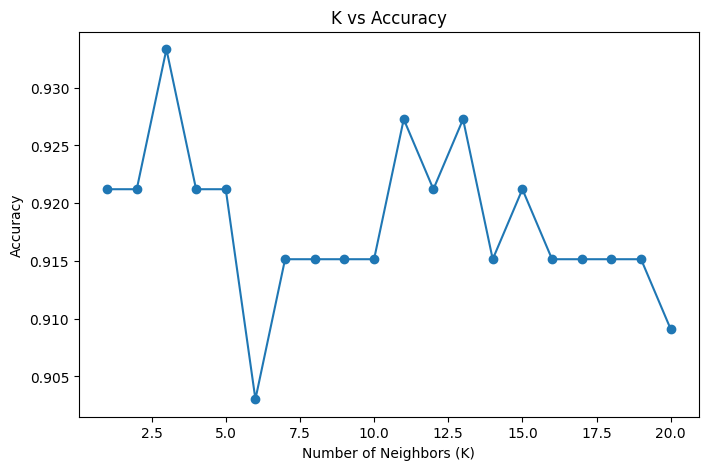

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, accuracies, marker='o')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.title('K vs Accuracy')
plt.show()

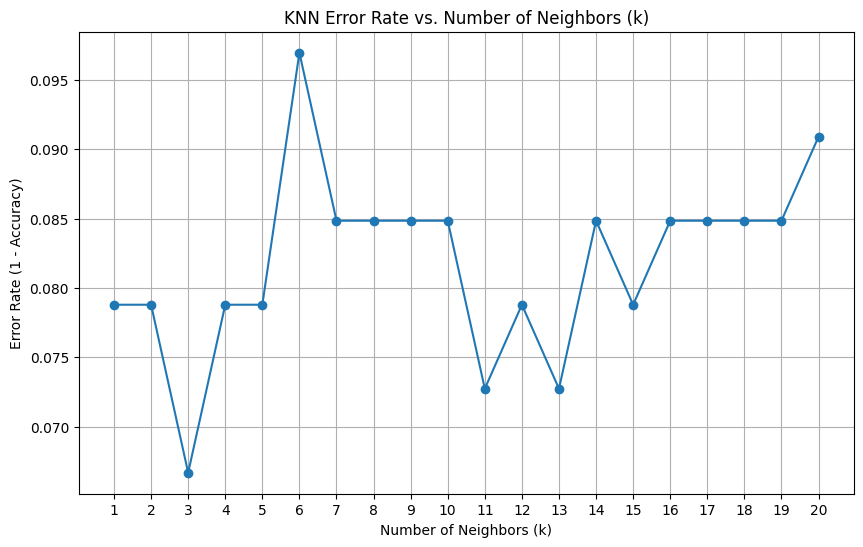

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# List to store error rates for different k values
error_rates = []

# Range of k values to test (e.g., from 1 to 20)
k_range = range(1, 21)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    error_rates.append(1 - accuracy_score(y_test, y_pred)) # Calculate error rate

# Plotting the elbow method results
plt.figure(figsize=(10, 6))
plt.plot(k_range, error_rates, marker='o', linestyle='-')
plt.title('KNN Error Rate vs. Number of Neighbors (k)')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate (1 - Accuracy)')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

The plot above shows the accuracy of the KNN model for different values of 'k'. We are looking for an 'elbow' point where the accuracy starts to level off or decrease significantly. This can help us narrow down the search space for 'k' for the Randomized Search.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_neighbors': range(1, 21),  # Based on elbow method, we can explore k from 1 to 20
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize RandomizedSearchCV
# n_iter: number of parameter settings that are sampled
# cv: number of folds for cross-validation
# scoring: metric to optimize
random_search_knn = RandomizedSearchCV(knn, param_distributions=param_dist, n_iter=100, cv=5, scoring='accuracy', random_state=42, n_jobs=-1)

# Fit RandomizedSearchCV to the training data
random_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", random_search_knn.best_params_)
print("Best cross-validation accuracy: ", random_search_knn.best_score_)

Best parameters found:  {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'manhattan'}
Best cross-validation accuracy:  0.9254221605366644


The Randomized Search will now explore different combinations of `n_neighbors`, `weights`, and `metric` to find the set of hyperparameters that yields the best cross-validation accuracy for the KNN model.

First 5 Tuned KNN predictions:
[0 1 0 1 0]

Classification Report for Tuned KNN:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96        94
           1       1.00      0.89      0.94        71

    accuracy                           0.95       165
   macro avg       0.96      0.94      0.95       165
weighted avg       0.96      0.95      0.95       165


Tuned KNN Accuracy: 0.9515
Tuned KNN ROC AUC Score: 0.9530


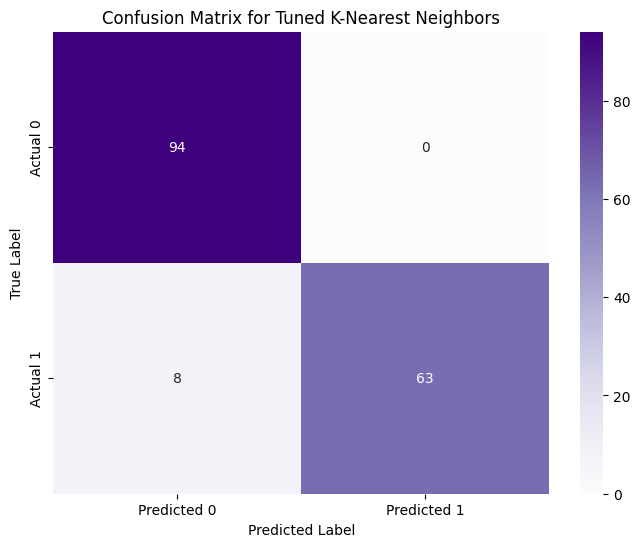

In [ ]:
# Get the best KNN model from RandomizedSearchCV
best_knn_model = random_search_knn.best_estimator_

# Make predictions on the test set using the best model
y_pred_best_knn = best_knn_model.predict(X_test)

print("First 5 Tuned KNN predictions:")
print(y_pred_best_knn[:5])

# Generate classification report for the tuned KNN
print("\nClassification Report for Tuned KNN:")
print(classification_report(y_test, y_pred_best_knn))

# Calculate Accuracy for the tuned KNN
accuracy_best_knn = accuracy_score(y_test, y_pred_best_knn)
print(f"\nTuned KNN Accuracy: {accuracy_best_knn:.4f}")

# Calculate ROC AUC for the tuned KNN (requires probability predictions)
roc_auc_best_knn = roc_auc_score(y_test, best_knn_model.predict_proba(X_test)[:, 1])
print(f"Tuned KNN ROC AUC Score: {roc_auc_best_knn:.4f}")

# Generate confusion matrix for the tuned KNN
conf_matrix_best_knn = confusion_matrix(y_test, y_pred_best_knn)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_knn, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned K-Nearest Neighbors')
plt.show()

Best parameters found with Grid Search:  {'metric': 'manhattan', 'n_neighbors': 6, 'weights': 'distance'}
Best cross-validation accuracy with Grid Search:  0.9254452926208652

Classification Report for Tuned KNN (Grid Search):
              precision    recall  f1-score   support

           0       0.90      1.00      0.95        94
           1       1.00      0.86      0.92        71

    accuracy                           0.94       165
   macro avg       0.95      0.93      0.94       165
weighted avg       0.95      0.94      0.94       165


Tuned KNN Accuracy (Grid Search): 0.9394
Tuned KNN ROC AUC Score (Grid Search): 0.9553


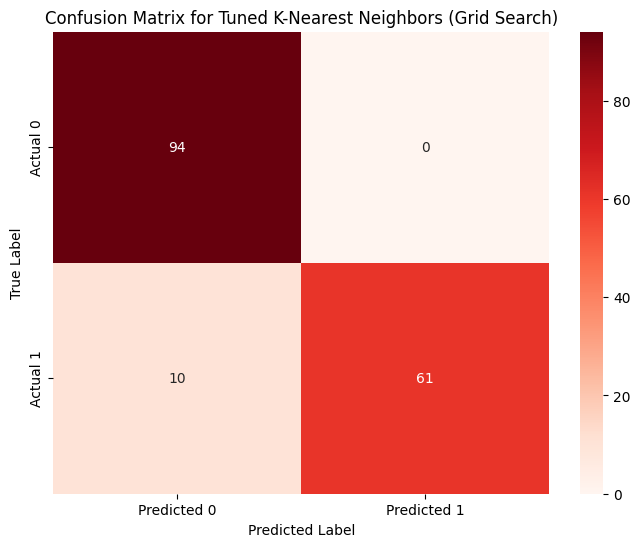

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Define the parameter grid for GridSearchCV
# We'll focus the search around the n_neighbors value that performed best in Randomized Search
param_grid = {
    'n_neighbors': list(range(1, 20)), # Focused range for k around the RandomizedSearchCV best k=3
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Initialize GridSearchCV
# cv: number of folds for cross-validation
# scoring: metric to optimize
grid_search_knn = GridSearchCV(knn, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_knn.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found with Grid Search: ", grid_search_knn.best_params_)
print("Best cross-validation accuracy with Grid Search: ", grid_search_knn.best_score_)

# Get the best KNN model from GridSearchCV
best_knn_model_grid = grid_search_knn.best_estimator_

# Make predictions on the test set using the best model from Grid Search
y_pred_best_knn_grid = best_knn_model_grid.predict(X_test)

# Generate classification report for the best KNN from Grid Search
print("\nClassification Report for Tuned KNN (Grid Search):")
print(classification_report(y_test, y_pred_best_knn_grid))

# Calculate Accuracy for the best KNN from Grid Search
accuracy_best_knn_grid = accuracy_score(y_test, y_pred_best_knn_grid)
print(f"\nTuned KNN Accuracy (Grid Search): {accuracy_best_knn_grid:.4f}")

# Calculate ROC AUC for the best KNN from Grid Search
roc_auc_best_knn_grid = roc_auc_score(y_test, best_knn_model_grid.predict_proba(X_test)[:, 1])
print(f"Tuned KNN ROC AUC Score (Grid Search): {roc_auc_best_knn_grid:.4f}")

# Generate confusion matrix for the best KNN from Grid Search
conf_matrix_best_knn_grid = confusion_matrix(y_test, y_pred_best_knn_grid)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_best_knn_grid, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Tuned K-Nearest Neighbors (Grid Search)')
plt.show()

## Cross Validation

### K-Fold Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Initialize Stratified K-Fold Cross-Validation
# n_splits = 5 is a common choice
# shuffle=True ensures data is randomly distributed before splitting
# random_state for reproducibility
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Prepare data for cross-validation (using the full scaled dataset)
X_full = df_scaled.drop('Class', axis=1)
y_full = df_scaled['Class']

# Lists to store metrics for each fold
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

print("Performing K-Fold Cross-Validation...")

for fold, (train_index, test_index) in enumerate(skf.split(X_full, y_full)):
    print(f"\n--- Fold {fold+1}/{skf.n_splits} ---")
    X_train_fold, X_test_fold = X_full.iloc[train_index], X_full.iloc[test_index]
    y_train_fold, y_test_fold = y_full.iloc[train_index], y_full.iloc[test_index]

    # Use the best KNN model found from GridSearchCV
    # (best_knn_model_grid is available from previous execution)
    best_knn_model_grid.fit(X_train_fold, y_train_fold)
    y_pred_fold = best_knn_model_grid.predict(X_test_fold)

    # Calculate and store metrics for the current fold
    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold))

    print(f"Accuracy: {accuracy_scores[-1]:.4f}")
    print(f"Precision: {precision_scores[-1]:.4f}")
    print(f"Recall: {recall_scores[-1]:.4f}")
    print(f"F1-Score: {f1_scores[-1]:.4f}")

print("\n--- Average K-Fold Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(accuracy_scores):.4f} (+/- {np.std(accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(precision_scores):.4f} (+/- {np.std(precision_scores):.4f})")
print(f"Average Recall: {np.mean(recall_scores):.4f} (+/- {np.std(recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(f1_scores):.4f} (+/- {np.std(f1_scores):.4f})")

Performing K-Fold Cross-Validation...

--- Fold 1/5 ---
Accuracy: 0.9152
Precision: 0.9524
Recall: 0.8451
F1-Score: 0.8955

--- Fold 2/5 ---
Accuracy: 0.9273
Precision: 0.9683
Recall: 0.8592
F1-Score: 0.9104

--- Fold 3/5 ---
Accuracy: 0.9329
Precision: 1.0000
Recall: 0.8451
F1-Score: 0.9160

--- Fold 4/5 ---
Accuracy: 0.9268
Precision: 1.0000
Recall: 0.8310
F1-Score: 0.9077

--- Fold 5/5 ---
Accuracy: 0.9512
Precision: 0.9701
Recall: 0.9155
F1-Score: 0.9420

--- Average K-Fold Cross-Validation Results ---
Average Accuracy: 0.9307 (+/- 0.0118)
Average Precision: 0.9782 (+/- 0.0189)
Average Recall: 0.8592 (+/- 0.0295)
Average F1-Score: 0.9143 (+/- 0.0154)


### Leave-one-out

In [ ]:
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Initialize Leave-One-Out Cross-Validation
loo = LeaveOneOut()

# Prepare data for cross-validation (using the full scaled dataset)
X_full = df_scaled.drop('Class', axis=1)
y_full = df_scaled['Class']

# Lists to store metrics for each fold
accuracy_scores_loo = []
precision_scores_loo = []
recall_scores_loo = []
f1_scores_loo = []

print("Performing Leave-One-Out Cross-Validation (this may take a while)...")

for train_index, test_index in loo.split(X_full):
    X_train_loo, X_test_loo = X_full.iloc[train_index], X_full.iloc[test_index]
    y_train_loo, y_test_loo = y_full.iloc[train_index], y_full.iloc[test_index]

    # Use the best KNN model found from GridSearchCV
    best_knn_model_grid.fit(X_train_loo, y_train_loo)
    y_pred_loo = best_knn_model_grid.predict(X_test_loo)

    # Calculate and store metrics for the current fold
    # Note: precision, recall, f1 might be undefined for a single class test set, handle division by zero
    accuracy_scores_loo.append(accuracy_score(y_test_loo, y_pred_loo))

    # Use zero_division parameter for precision/recall/f1 score calculations
    precision_scores_loo.append(precision_score(y_test_loo, y_pred_loo, zero_division=0))
    recall_scores_loo.append(recall_score(y_test_loo, y_pred_loo, zero_division=0))
    f1_scores_loo.append(f1_score(y_test_loo, y_pred_loo, zero_division=0))

print(X_train_loo.shape,X_test_loo.shape)

print("\n--- Average Leave-One-Out Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(accuracy_scores_loo):.4f}")
print(f"Average Precision: {np.mean(precision_scores_loo):.4f}")
print(f"Average Recall: {np.mean(recall_scores_loo):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores_loo):.4f}")

Performing Leave-One-Out Cross-Validation (this may take a while)...
(821, 30) (1, 30)

--- Average Leave-One-Out Cross-Validation Results ---
Average Accuracy: 0.9307
Average Precision: 0.3686
Average Recall: 0.3686
Average F1-Score: 0.3686


### Nested Cross-Validation

Nested cross-validation is used to obtain a more reliable estimate of the model's generalization performance and to prevent overfitting to the validation set during hyperparameter tuning. It consists of an outer loop for evaluating the model and an inner loop for hyperparameter optimization.

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Prepare data for cross-validation (using the full scaled dataset)
X_full = df_scaled.drop('Class', axis=1)
y_full = df_scaled['Class']

# Outer K-Fold Cross-Validation
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Inner K-Fold Cross-Validation for hyperparameter tuning
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Define the parameter grid for GridSearchCV (re-using the one from GridSearchCV cell)
param_grid = {
    'n_neighbors': list(range(1, 20)),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Initialize KNN classifier
knn = KNeighborsClassifier()

# Lists to store metrics for the outer folds
outer_accuracy_scores = []
outer_precision_scores = []
outer_recall_scores = []
outer_f1_scores = []

print("Performing Nested Cross-Validation...")

for i, (train_index_outer, test_index_outer) in enumerate(outer_cv.split(X_full, y_full)):
    print(f"\n--- Outer Fold {i+1}/{outer_cv.n_splits} ---")
    X_train_outer, X_test_outer = X_full.iloc[train_index_outer], X_full.iloc[test_index_outer]
    y_train_outer, y_test_outer = y_full.iloc[train_index_outer], y_full.iloc[test_index_outer]

    # Inner loop: GridSearchCV for hyperparameter tuning on the outer training set
    grid_search = GridSearchCV(knn, param_grid=param_grid, cv=inner_cv, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_outer, y_train_outer)

    best_knn_model_nested = grid_search.best_estimator_
    print(f"Best parameters for Outer Fold {i+1}: {grid_search.best_params_}")

    # Evaluate the best model from inner loop on the outer test set
    y_pred_nested = best_knn_model_nested.predict(X_test_outer)

    outer_accuracy_scores.append(accuracy_score(y_test_outer, y_pred_nested))
    outer_precision_scores.append(precision_score(y_test_outer, y_pred_nested, zero_division=0))
    outer_recall_scores.append(recall_score(y_test_outer, y_pred_nested, zero_division=0))
    outer_f1_scores.append(f1_score(y_test_outer, y_pred_nested, zero_division=0))

    print(f"Accuracy: {outer_accuracy_scores[-1]:.4f}")
    print(f"Precision: {outer_precision_scores[-1]:.4f}")
    print(f"Recall: {outer_recall_scores[-1]:.4f}")
    print(f"F1-Score: {outer_f1_scores[-1]:.4f}")

print("\n--- Average Nested Cross-Validation Results ---")
print(f"Average Accuracy: {np.mean(outer_accuracy_scores):.4f} (+/- {np.std(outer_accuracy_scores):.4f})")
print(f"Average Precision: {np.mean(outer_precision_scores):.4f} (+/- {np.std(outer_precision_scores):.4f})")
print(f"Average Recall: {np.mean(outer_recall_scores):.4f} (+/- {np.std(outer_recall_scores):.4f})")
print(f"Average F1-Score: {np.mean(outer_f1_scores):.4f} (+/- {np.std(outer_f1_scores):.4f})")

Performing Nested Cross-Validation...

--- Outer Fold 1/5 ---
Best parameters for Outer Fold 1: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy: 0.9212
Precision: 0.9531
Recall: 0.8592
F1-Score: 0.9037

--- Outer Fold 2/5 ---
Best parameters for Outer Fold 2: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy: 0.9333
Precision: 0.9839
Recall: 0.8592
F1-Score: 0.9173

--- Outer Fold 3/5 ---
Best parameters for Outer Fold 3: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy: 0.9390
Precision: 1.0000
Recall: 0.8592
F1-Score: 0.9242

--- Outer Fold 4/5 ---
Best parameters for Outer Fold 4: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy: 0.8963
Precision: 0.9355
Recall: 0.8169
F1-Score: 0.8722

--- Outer Fold 5/5 ---
Best parameters for Outer Fold 5: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Accuracy: 0.9512
Precision: 0.9701
Recall: 0.9155
F1-Score: 0.9420

--- Average